In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("german_credit_data.csv")

In [4]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [6]:
# Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)

df["Job"].value_counts()

2    630
1    200
3    148
0     22
Name: Job, dtype: int64

In [7]:
df["Saving accounts"].value_counts()

little        603
moderate      103
quite rich     63
rich           48
Name: Saving accounts, dtype: int64

In [8]:
df["Checking account"].value_counts()

little      274
moderate    269
rich         63
Name: Checking account, dtype: int64

In [9]:
df["Risk"].value_counts()

good    700
bad     300
Name: Risk, dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Checking for null values
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [13]:
# Checking for duplicate rows
df.duplicated().sum()

0

In [14]:
# Rows having null values in both the columns
df_null=df[(df["Saving accounts"].isna()) & (df["Checking account"].isna())]

In [15]:
len(df_null)

99

In [16]:
df_null["Risk"].value_counts()

good    90
bad      9
Name: Risk, dtype: int64

In [17]:
# Indicates null values of saving accounts and checking account doesn't necessarily translate to bad risk
# So marking them as a new category "none" instead of discarding them

df["Saving accounts"]=df["Saving accounts"].fillna('none')
df["Checking account"]=df["Checking account"].fillna('none')

In [18]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [19]:
df.drop(columns='Unnamed: 0',inplace=True)

In [20]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

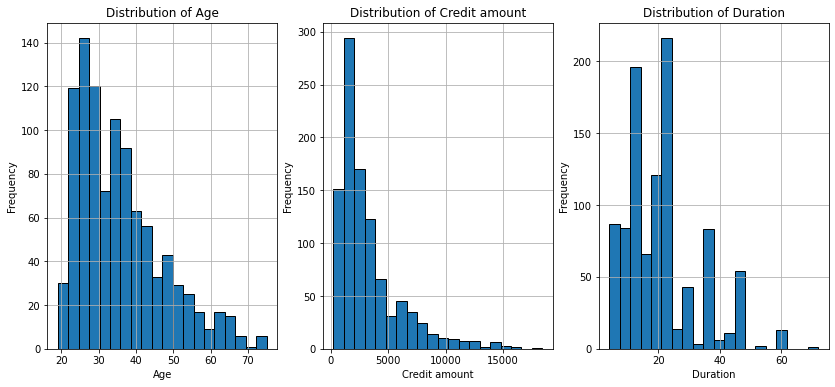

In [21]:
# Visualization of distributions

cols=["Age","Credit amount","Duration"]
plt.figure(figsize=(14,6))
for i,col in enumerate(cols):
    plt.subplot(1,3,i+1)
    df[col].hist(bins=20,edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.show()

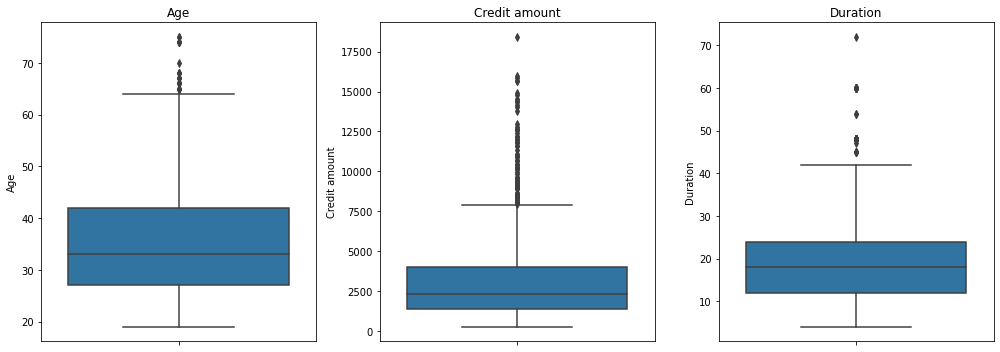

In [22]:
# Analyzing outliers

plt.figure(figsize=(14,5))
for i,col in enumerate(cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [23]:
df.query("Age >= 70")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
163,70,male,3,free,little,moderate,7308,10,car,good
186,74,female,3,free,little,moderate,5129,9,car,bad
330,75,male,3,free,little,little,6615,24,car,good
430,74,male,1,own,little,none,3448,5,business,good
536,75,female,3,own,none,little,1374,6,car,good
606,74,male,3,own,little,none,4526,24,business,good
756,74,male,0,own,little,rich,1299,6,car,good


In [24]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,none,10144,60,radio/TV,good
255,27,male,1,own,none,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,none,none,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,none,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,none,15653,60,radio/TV,good
672,42,male,3,own,little,none,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [25]:
df.query("`Credit amount` >= 15000")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
95,58,male,2,rent,little,moderate,15945,54,business,bad
637,21,male,2,own,little,none,15653,60,radio/TV,good
818,43,male,3,own,little,little,15857,36,vacation/others,good
887,23,male,2,own,little,moderate,15672,48,business,bad
915,32,female,3,own,little,moderate,18424,48,vacation/others,bad


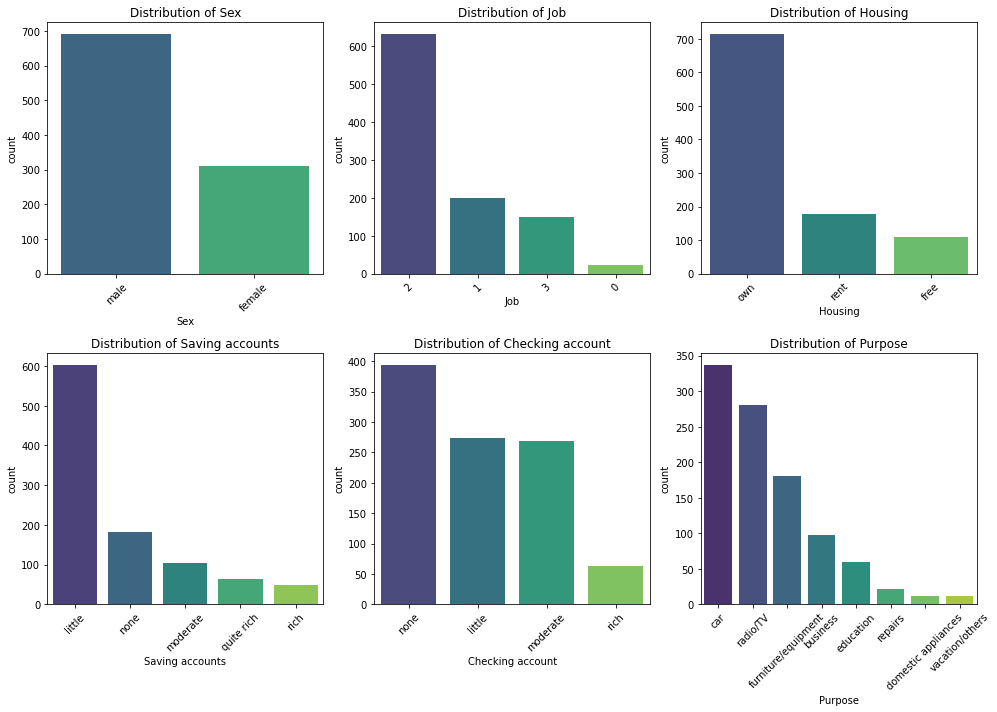

In [26]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
target_col = ['Risk']

plt.figure(figsize=(14,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(data=df, x=col, palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

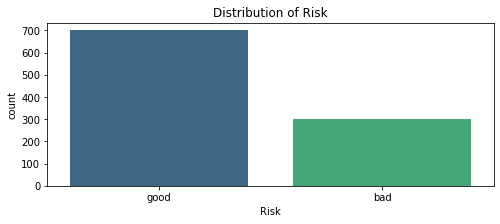

In [27]:
plt.figure(figsize=(8,3))
sns.countplot(x=df['Risk'], palette='viridis', order=df["Risk"].value_counts().index)
plt.title('Distribution of Risk')
plt.show()

In [28]:
# Correlation among features

corr=df[["Age","Job","Credit amount","Duration"]].corr()

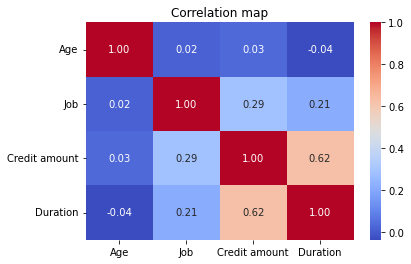

In [29]:
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation map")
plt.show()

In [30]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [31]:
df.groupby("Job")["Credit amount"].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [32]:
df.groupby("Risk")["Credit amount"].mean()

Risk
bad     3938.126667
good    2985.457143
Name: Credit amount, dtype: float64

In [33]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Saving accounts")

Saving accounts,little,moderate,none,quite rich,rich
Housing,,,,,
free,4545.313433,5138.500000,6423.695652,3919.000000,1345.500000
own,3021.225581,3018.929577,3535.346154,2492.111111,2628.081081
rent,3005.660377,3764.863636,3584.433333,2198.666667,2621.444444


In [34]:
pd.pivot_table(df,values="Credit amount",index="Risk",columns="Saving accounts")

#Result indicates customers with bad risk borrow more than ones with good risk and rich ones are borrowing less compared to other saving accounts

Saving accounts,little,moderate,none,quite rich,rich
Risk,,,,,
bad,3925.557604,4006.970588,4362.062500,3052.818182,3364.666667
good,2773.101036,3077.086957,3809.847682,2470.423077,2460.357143


In [35]:
pd.pivot_table(df,values="Credit amount",index="Risk",columns="Checking account")

Checking account,little,moderate,none,rich
Risk,,,,
bad,3413.607407,4754.752381,4286.782609,1725.714286
good,2943.690647,3233.932927,2980.603448,2306.775510


In [36]:
# Both the above outputs indicate customers with rich savings account or checking account are relatively borrowing less than others

In [37]:
pd.pivot_table(df,values="Duration",columns="Saving accounts",index="Risk")

Saving accounts,little,moderate,none,quite rich,rich
Risk,,,,,
bad,25.027650,27.558824,22.718750,22.636364,19.000000
good,17.862694,20.362319,22.715232,18.269231,18.214286


In [38]:
# Indicating customers with good risk pays back in relatively lesser duration

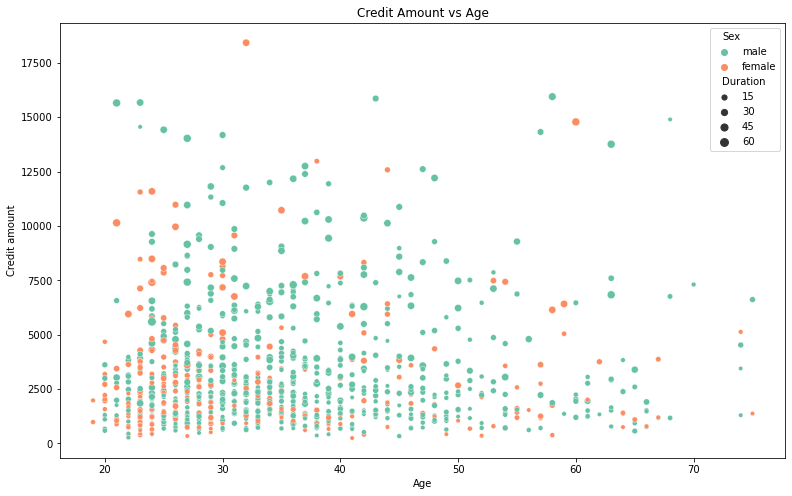

In [39]:
plt.figure(figsize=(13,8))
sns.scatterplot(data=df,x="Age",y="Credit amount",hue="Sex",size="Duration",palette="Set2")
plt.title("Credit Amount vs Age")
plt.show()

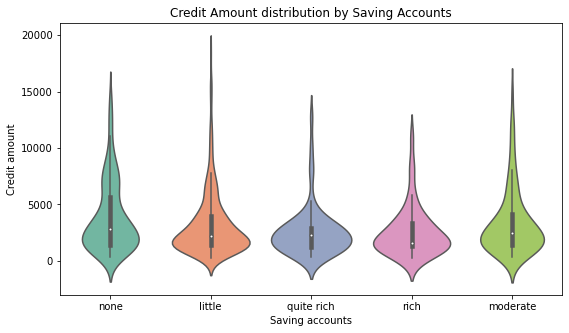

In [40]:
plt.figure(figsize=(9,5))
sns.violinplot(data=df,x="Saving accounts",y="Credit amount",palette="Set2")
plt.title("Credit Amount distribution by Saving Accounts")
plt.show()

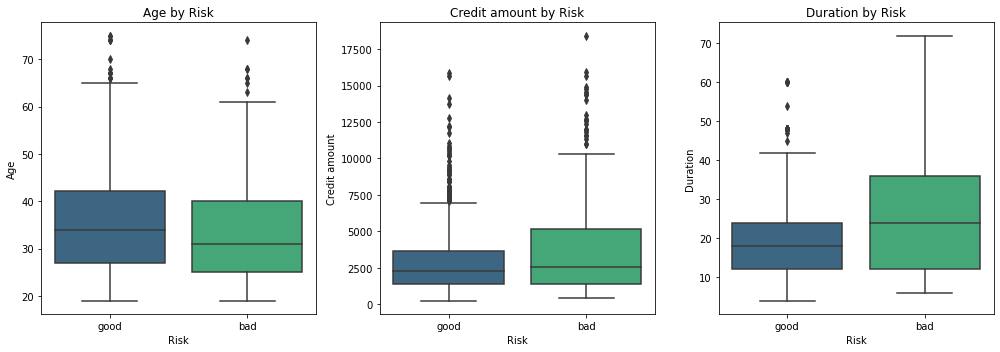

In [41]:
plt.figure(figsize=(14,5))
for i,col in enumerate(cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x="Risk", y=col, palette='viridis')
    plt.title(f'{col} by Risk')
plt.tight_layout()
plt.show()

In [42]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


In [43]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].median()

,Age,Credit amount,Duration
Risk,,,
bad,31.0,2574.5,24.0
good,34.0,2244.0,18.0


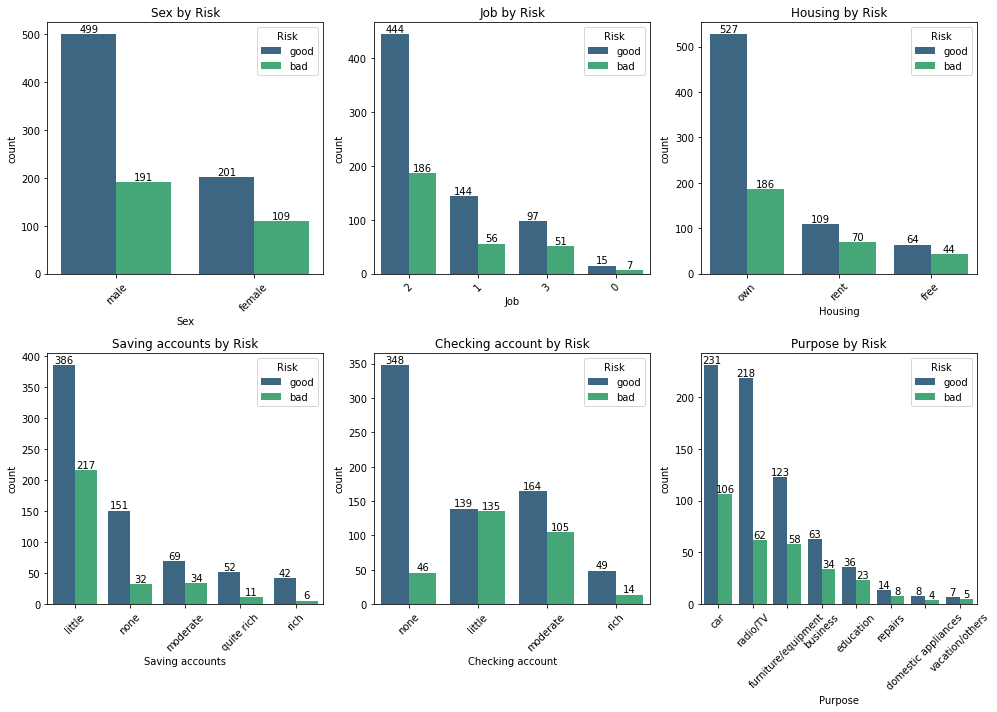

In [44]:
plt.figure(figsize=(14,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(2,3,i+1)
    ax=sns.countplot(data=df, x=col, palette='viridis', hue="Risk", order=df[col].value_counts().index)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'{col} by Risk')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
### Insights
# Liquidity related features show the strongest seperation between good and bad risk, with certain categories exhibiting
# a good to bad ratio as high as 7-8, while most demographic or occupational features remain below 5.
# This indicates short term financial stability is a more decisive driver of credit worthiness than personal attributes.

In [46]:
df_1= df.drop(columns=["Risk"])

In [47]:
df_1.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,none,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,none,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [48]:
# Encoding categorical features

df_final=df.copy()

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

le_target=LabelEncoder()
df_final["Risk"]=le_target.fit_transform(df_final["Risk"])

onehot_features=["Purpose","Housing","Sex"]
df_encoded=pd.get_dummies(df_final,columns=onehot_features,drop_first=True)

saving_map={"none":0,"little":1,"moderate":2,"rich":3,"quite rich":4}
checking_map={"none":0,"little":1,"moderate":2,"rich":3}
df_encoded["Saving accounts"]=df_encoded["Saving accounts"].map(saving_map)
df_encoded["Checking account"]=df_encoded["Checking account"].map(checking_map)


df_encoded=df_encoded.drop(columns=["Risk"])

In [49]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          1000 non-null   int64
 1   Job                          1000 non-null   int64
 2   Saving accounts              1000 non-null   int64
 3   Checking account             1000 non-null   int64
 4   Credit amount                1000 non-null   int64
 5   Duration                     1000 non-null   int64
 6   Purpose_car                  1000 non-null   uint8
 7   Purpose_domestic appliances  1000 non-null   uint8
 8   Purpose_education            1000 non-null   uint8
 9   Purpose_furniture/equipment  1000 non-null   uint8
 10  Purpose_radio/TV             1000 non-null   uint8
 11  Purpose_repairs              1000 non-null   uint8
 12  Purpose_vacation/others      1000 non-null   uint8
 13  Housing_own                  1000 non-null   uint

In [50]:
df_final["Risk"]

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int32

In [51]:
df_final["Risk"].value_counts()

1    700
0    300
Name: Risk, dtype: int64

In [52]:
df_encoded.head()

,Age,Job,Saving accounts,Checking account,Credit amount,Duration,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Housing_own,Housing_rent,Sex_male
0,67,2,0,1,1169,6,0,0,0,0,1,0,0,1,0,1
1,22,2,1,2,5951,48,0,0,0,0,1,0,0,1,0,0
2,49,1,1,0,2096,12,0,0,1,0,0,0,0,1,0,1
3,45,2,1,1,7882,42,0,0,0,1,0,0,0,0,0,1
4,53,2,1,1,4870,24,1,0,0,0,0,0,0,0,0,1


In [53]:
X=df_encoded
y=df_final["Risk"]

In [54]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [55]:
y_train.value_counts()

1    560
0    240
Name: Risk, dtype: int64

In [56]:
y_test.value_counts()

1    140
0     60
Name: Risk, dtype: int64

In [57]:
# The target variable distribution is consistently maintained (70% good(1), 30% bad(0))

In [58]:
X_train.shape

(800, 16)

In [59]:
X_test.shape

(200, 16)

In [60]:
X_train.head

<bound method NDFrame.head of      Age  Job  Saving accounts  Checking account  Credit amount  Duration  \
675   26    3                1                 0           4530        30   
703   41    2                2                 2           2503        30   
12    22    2                1                 2           1567        12   
845   35    2                0                 2           3976        21   
795   22    2                2                 0           2301         9   
..   ...  ...              ...               ...            ...       ...   
284   37    2                2                 2           3878        24   
169   31    2                1                 2           1935        24   
856   40    2                0                 0            894        10   
655   22    2                1                 1           3973        14   
695   50    2                4                 0           1236         6   

     Purpose_car  Purpose_domestic appliances

In [61]:
# Using a baseline model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,precision_score,recall_score

lr=LogisticRegression(max_iter=500,random_state=42)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.43      0.27      0.33        60
           1       0.73      0.85      0.79       140

    accuracy                           0.68       200
   macro avg       0.58      0.56      0.56       200
weighted avg       0.64      0.68      0.65       200



In [62]:
lr=LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.43      0.65      0.52        60
           1       0.81      0.63      0.71       140

    accuracy                           0.64       200
   macro avg       0.62      0.64      0.61       200
weighted avg       0.69      0.64      0.65       200



In [63]:
y_prob=lr.predict_proba(X_test)[:,1]
y_prob

array([0.50182886, 0.17706727, 0.26785476, 0.62888747, 0.20138915,
       0.34307021, 0.7309469 , 0.75737788, 0.33278542, 0.79734174,
       0.40100624, 0.51077872, 0.38211349, 0.33286295, 0.54987175,
       0.24495986, 0.5027968 , 0.76201827, 0.64654738, 0.53856759,
       0.32170963, 0.72700389, 0.57946886, 0.7793413 , 0.62609186,
       0.29446752, 0.21968492, 0.29188729, 0.74024554, 0.29312232,
       0.68467528, 0.46615709, 0.47323573, 0.69088935, 0.27922958,
       0.34672902, 0.24564984, 0.3283224 , 0.68638546, 0.60171214,
       0.47495832, 0.46073739, 0.73221745, 0.48118262, 0.33425538,
       0.12496991, 0.34079451, 0.68328817, 0.13133471, 0.70195835,
       0.62283038, 0.41003687, 0.64609842, 0.7696274 , 0.67026643,
       0.80039704, 0.88539013, 0.50930616, 0.80315538, 0.41539204,
       0.61971317, 0.6914504 , 0.73886206, 0.74479837, 0.276641  ,
       0.77411469, 0.73547266, 0.67708254, 0.63067918, 0.71319011,
       0.81108303, 0.16904237, 0.42813144, 0.63500947, 0.87689

In [64]:
thresholds=np.arange(0.2,0.8,0.05)
results=[]
for t in thresholds:
    y_pred_thresh=(y_prob>=t).astype(int)
    recall_bad=recall_score(y_test,y_pred_thresh,pos_label=0)
    precision_bad=precision_score(y_test,y_pred_thresh,pos_label=0)
    results.append((t,recall_bad,precision_bad))

In [65]:
threshold_df=pd.DataFrame(results,columns=["Threshold","Recall_Bad","Precision_Bad"])
threshold_df

,Threshold,Recall_Bad,Precision_Bad
0,0.20,0.116667,0.466667
1,0.25,0.150000,0.360000
2,0.30,0.300000,0.473684
3,0.35,0.433333,0.448276
4,0.40,0.483333,0.453125
5,0.45,0.566667,0.441558
6,0.50,0.650000,0.428571
7,0.55,0.700000,0.388889
8,0.60,0.750000,0.381356
9,0.65,0.833333,0.347222


In [66]:
# From 0.55 to 0.6 there is significant increase in recall with a similar precision
# But from 0.6 to 0.65 there is a decrease in precision along with increase in recall

# Hence, threshold is chosen as 0.6

In [67]:
y_prob=lr.predict_proba(X_test)[:,1]
final_threshold=0.6
y_pred_lr=(y_prob>=final_threshold).astype(int)
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.38      0.75      0.51        60
           1       0.82      0.48      0.60       140

    accuracy                           0.56       200
   macro avg       0.60      0.61      0.55       200
weighted avg       0.69      0.56      0.57       200



In [68]:
# Threshold tuning allowed the model to prioritize detection of high risk customers at the cost of rejecting more low-risk
# customers. To improve the identification of high-risk customers, proceeding to tree model that can capture non linear relationships

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [70]:
# Decision Tree

dt=DecisionTreeClassifier(max_depth=5,min_samples_split=30,criterion='gini',random_state=42,class_weight='balanced')
dt.fit(X_train,y_train)
dt_pred=dt.predict(X_test)
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.45      0.87      0.59        60
           1       0.90      0.54      0.68       140

    accuracy                           0.64       200
   macro avg       0.68      0.70      0.63       200
weighted avg       0.77      0.64      0.65       200



In [71]:
# Recall of 0.87 for the class Bad(0) shows model is very aggressive at catching bad customers
# On the other hand, precision of 0.45 for the class Bad(0) indicates it does so by flagging many good customers as bad

In [72]:
# Random Forest to improve generalization and reduce false positives
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=5,min_samples_split=20,bootstrap=True,class_weight='balanced_subsample',random_state=42,oob_score=True)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.46      0.77      0.57        60
           1       0.86      0.61      0.71       140

    accuracy                           0.66       200
   macro avg       0.66      0.69      0.64       200
weighted avg       0.74      0.66      0.67       200



In [73]:
# Improving recall for bad customers comes at the cost of misclassifying significant amount of good customers, regardless of model

# The model's behavior reflects realistic scenarios where conservative policies reduce default risk but increase false rejections

# The trade-off must therefore be aligned with risk tolerance rather than purely maximizing accuracy


In [74]:
# XGBoost

from xgboost import XGBClassifier

xgb=XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,objective='binary:logistic',eval_metric='logloss',random_state=42)
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57        60
           1       0.81      0.89      0.85       140

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.76      0.78      0.76       200



In [75]:
# Increase in precision, Decrease in recall, Increase in accuracy

In [76]:
# Parameter tuning to check for any further gains

param_grid={
    "max_depth":[3,4,5,6],
    "learning_rate":[0.05,0.1,0.2],
    "n_estimators":[100,150,200],
    "subsample":[0.7,1],
    "colsample_bytree":[0.7,1]
}
xgb1=XGBClassifier(random_state=42,scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),eval_metric="logloss")

from sklearn.metrics import make_scorer,recall_score
recall_bad=make_scorer(recall_score,pos_label=0)
grid=GridSearchCV(estimator=xgb1,
                 param_grid=param_grid,
                 scoring=recall_bad,
                 cv=5,
                 n_jobs=-1,
                 verbose=1)
grid.fit(X_train,y_train)
grid.best_params_

Fitting 5 folds for each of 144 candidates, totalling 720 fits


{'colsample_bytree': 0.7,
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 100,
 'subsample': 1}

In [77]:
grid.best_score_

0.7333333333333333

In [78]:
xgb1=XGBClassifier(n_estimators=250,max_depth=4,learning_rate=0.2,objective='binary:logistic',eval_metric='logloss',random_state=42)
xgb1.fit(X_train,y_train)
xgb1_pred=xgb1.predict(X_test)
print(classification_report(y_test,xgb1_pred))

              precision    recall  f1-score   support

           0       0.57      0.48      0.52        60
           1       0.79      0.84      0.82       140

    accuracy                           0.73       200
   macro avg       0.68      0.66      0.67       200
weighted avg       0.72      0.73      0.73       200



In [79]:
# Going with the previous XGBoost model considering the recall and precision metrics

In [80]:
y_prob_xgb=xgb.predict_proba(X_test)[:,1]
thresholds=np.arange(0.55,0.7,0.01)
results=[]
for t in thresholds:
    y_pred_thresh=(y_prob_xgb>=t).astype(int)
    recall_bad=recall_score(y_test,y_pred_thresh,pos_label=0)
    precision_bad=precision_score(y_test,y_pred_thresh,pos_label=0)
    results.append((t,recall_bad,precision_bad))
threshold_df=pd.DataFrame(results,columns=["Threshold","Recall_Bad","Precision_Bad"])
threshold_df

,Threshold,Recall_Bad,Precision_Bad
0,0.55,0.533333,0.592593
1,0.56,0.533333,0.592593
2,0.57,0.533333,0.592593
3,0.58,0.533333,0.571429
4,0.59,0.583333,0.564516
5,0.60,0.616667,0.560606
6,0.61,0.633333,0.550725
7,0.62,0.666667,0.555556
8,0.63,0.666667,0.547945
9,0.64,0.666667,0.540541


In [81]:
# Selecting 0.65 as a threshold as it provides a balanced operating point with 68% recall while maintaining acceptable precision

In [82]:
y_prob_xgb=xgb.predict_proba(X_test)[:,1]
final_threshold=0.65
y_pred_xgb=(y_prob_xgb>=final_threshold).astype(int)
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.53      0.68      0.60        60
           1       0.85      0.74      0.79       140

    accuracy                           0.73       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.75      0.72      0.73       200



In [83]:
cm=confusion_matrix(y_test,y_pred_xgb)
cm

array([[ 41,  19],
       [ 36, 104]], dtype=int64)

<Figure size 432x360 with 0 Axes>

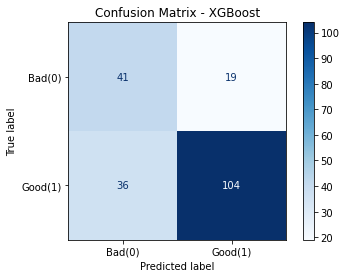

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay

disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Bad(0)","Good(1)"],
                           )
plt.figure(figsize=(6,5))
disp.plot(cmap="Blues",values_format="d")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [85]:
### INSIGHTS

# Bad Risk Class
# Recall=41/(41+19)=68%    captures 68% of risky applicants, directly reducing default risk
# Precision=41/(41+36)=53%

# Good Risk Class
# Recall=104/(104+36)=74%
# Precision=104/(104+19)=85%  Most(85%) of approved applicants are actually good

# Some good customers are intentionally rejected to avoid costly bad approvals.

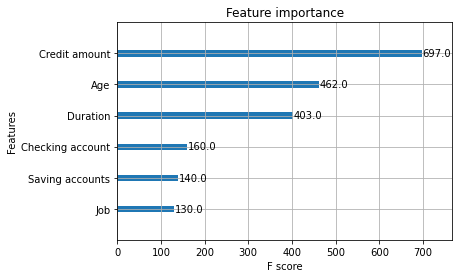

In [86]:
from xgboost import plot_importance

plot_importance(xgb,max_num_features=6)
plt.show()

In [87]:
# Feature importance analysis using XGBoost shows that Credit Amount, Age, DUration are the most influential factors
# Financial features such as checking account and saving accounts contribute moderately

In [88]:
# Model Performance Summary

model_comparison = pd.DataFrame({
    "Model":["Logistic Regression"," Decision Tree", "Random Forest", " XGBoost(Original)", "XGBoost (Tuned threshold)"],
    "Accuracy": [0.68,0.64,0.66,0.78,0.73],
    "Recall (Bad)":[0.27,0.87,0.77,0.50,0.68],
    "Precision(Bad)":[0.43,0.45,0.46,0.67,0.53],
    "Recall (Good)":[0.85,0.54,0.61,0.89,0.74],
    "Precision (Bad)":[0.73,0.90,0.86,0.81,0.85],
    "Threshold Used":["Default","Default","Default","Default",0.65]
})
model_comparison

,Model,Accuracy,Recall (Bad),Precision(Bad),Recall (Good),Precision (Bad),Threshold Used
0,Logistic Regression,0.68,0.27,0.43,0.85,0.73,Default
1,Decision Tree,0.64,0.87,0.45,0.54,0.90,Default
2,Random Forest,0.66,0.77,0.46,0.61,0.86,Default
3,XGBoost(Original),0.78,0.50,0.67,0.89,0.81,Default
4,XGBoost (Tuned threshold),0.73,0.68,0.53,0.74,0.85,0.65


In [89]:
# Logistic Regression: decent, but doesn't capture non linear relationships
# Decision Tree, Random Forest: Imbalanced recall,precision (The least for Good class among all the models)
# XGBoost(Original): High good-class recall and precision, bad-class recall is low(50%), risky appplicants are under-identified
# XGBoost (Threshold-tuned): Bad-class recall increases to 68% at the cost of slight drop in good-class recall

In [90]:
### LIMITATIONS

# Model Performance is constrained by limited feature richness and absence of behavioral or transactional variables
# The model was optimized for high-risk recall rather than overall accuracy
# Moderate performance metrics are expected for traditional tabular credit datasets, where risk patterns are noisy and partially overlapping

In [91]:
# Further enhancements
# Risk banding

xgb_model=XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,objective='binary:logistic',eval_metric='logloss',random_state=42)
xgb_model.fit(X_train,y_train)

y_prob_bad=xgb_model.predict_proba(X_test)[:,0]

<Figure size 432x360 with 0 Axes>

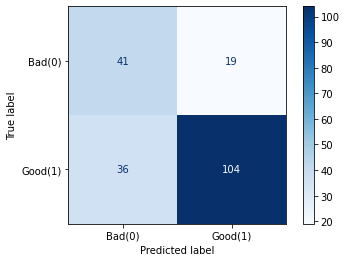

In [92]:
threshold=0.35

y_pred_final=np.where(y_prob_bad>=threshold,0,1)
cm=confusion_matrix(y_test,y_pred_final)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Bad(0)","Good(1)"],
                           )
plt.figure(figsize=(6,5))
disp.plot(cmap="Blues",values_format="d")
plt.show()

In [93]:
print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.53      0.68      0.60        60
           1       0.85      0.74      0.79       140

    accuracy                           0.73       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.75      0.72      0.73       200



In [94]:
risk_df=X_test.copy()
risk_df["actual_risk"]=y_test.values
risk_df["prob_bad"]=y_prob_bad

In [95]:
def risk_band(p):
    if p>=0.65:
        return "High Risk"
    elif p>=0.45:
        return "Medium Risk"
    else:
        return "Low Risk"

In [96]:
risk_df["Risk band"]=risk_df["prob_bad"].apply(risk_band)

In [97]:
risk_df["Risk band"].value_counts(normalize=True)

Low Risk       0.730
Medium Risk    0.175
High Risk      0.095
Name: Risk band, dtype: float64

In [98]:
# Risk rates per band
ct=pd.crosstab(risk_df["Risk band"],risk_df["actual_risk"],normalize="index")
ct=ct.reindex(["High Risk","Medium Risk","Low Risk"])
ct

actual_risk,0,1
Risk band,,
High Risk,0.736842,0.263158
Medium Risk,0.514286,0.485714
Low Risk,0.191781,0.808219


In [99]:
### INSIGHTS

# Monotonic increase in bad rates across bands
# Medium risk band is balanced
# Low risk band is safe

# Applicants were segmented into three risk bands using predicted default probability
# The above values demonstrates the model's ability to effectively rank credit risk and support actionable decision making

In [100]:
# Policy Implementations based on above banding

In [101]:
# 1. Approve all

approve_all=risk_df.copy()
expected_bad=approve_all["actual_risk"].value_counts()[0]
# No of bad applicants approved
tot_approved=len(approve_all)
def_rate=expected_bad/tot_approved

print(f"Total Approved: {tot_approved}")
print(f"Expected defaults: {expected_bad}")
print(f"Default Rate: {def_rate:.2%}")

Total Approved: 200
Expected defaults: 60
Default Rate: 30.00%


In [102]:
# 2. Accepting applicants from low and medium risk only

low_med=risk_df[risk_df["Risk band"].isin(["Low Risk","Medium Risk"])]
expected_bad=low_med["actual_risk"].value_counts()[0]
# No of bad applicants approved
tot_approved=len(low_med)
def_rate=expected_bad/tot_approved

print(f"Total Approved: {tot_approved}")
print(f"Expected defaults: {expected_bad}")
print(f"Default Rate: {def_rate:.2%}")

Total Approved: 181
Expected defaults: 46
Default Rate: 25.41%


In [103]:
# 3. Accepting applicants from low risk only

low=risk_df[risk_df["Risk band"].isin(["Low Risk"])]
expected_bad=low["actual_risk"].value_counts()[0]
# No of bad applicants approved
tot_approved=len(low)
def_rate=expected_bad/tot_approved

print(f"Total Approved: {tot_approved}")
print(f"Expected defaults: {expected_bad}")
print(f"Default Rate: {def_rate:.2%}")

Total Approved: 146
Expected defaults: 28
Default Rate: 19.18%


In [104]:
### OBSERVATIONS

# Policy 1: Approving all maximizes credit volume but has highest default risk of 30%   -> Maximize volume
# Policy 2: Reduces default risk to 25.4% while still approving most applicants(181/200 = 90.5%) -> Balance growth and defaults
# Policy 3: Lowest default rate but approves fewer applicants(146/200 = 73%)   -> Minimize defaults